## Severity based Feature Engineering
This notebook contains the complete severity-based predictive maintenance workflow developed during the project. The notebook processes triaxial vibration waveform data collected under normal, unbalance, misalignment, and mechanical looseness conditions across multiple RPM levels and severity ranges.
The workflow includes raw signal preprocessing, dataset construction, feature engineering, FFT-based spectral analysis, and time-series preparation for advanced modelling approaches. Multiple machine learning, deep learning, and time-series classification models were explored and compared throughout the notebook. These included ExtraTrees, Random Forest, XGBoost, LightGBM, 1D CNN, ResNet-based models, InceptionTime-inspired architectures, Dual-Branch CNN models, Multi-Scale Dual Encoder models, and MiniRocket with Ridge Classification.
Extensive comparative analysis was performed using accuracy, weighted F1-score, macro F1-score, classification reports, and confusion matrices to evaluate each model’s performance under different fault severity conditions. The notebook also contains visualization components such as waveform plots, FFT analysis, vibration monitoring graphs, and dashboard-oriented predictive maintenance visualizations designed for real-time machinery health monitoring.


In [ ]:
!pip install xgboost lightgbm sktime tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 9.4 MB/s eta 0:00:00


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.linear_model import RidgeClassifierCV
from sktime.transformations.panel.rocket import MiniRocketMultivariate

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation, Add,
    GlobalAveragePooling1D, Dense, Dropout, Concatenate,
    MaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving final data for severity based modelling.zip to final data for severity based modelling.zip


In [ ]:
import zipfile

zip_path = list(uploaded.keys())[0]   # if using files.upload()

extract_path = "/content/data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully")

Extracted successfully


In [ ]:
data_path = "/content/data/final data for severity based modelling"

In [ ]:
import os
import json

samples = []

def get_label(filename):
    name = filename.lower()

    if "normal" in name:
        return "normal"

    if "unbalance" in name:
        if "low" in name: return "unbalance_low"
        if "medium" in name: return "unbalance_medium"
        if "high" in name: return "unbalance_high"

    if "misalignment" in name:
        if "low" in name: return "misalignment_low"
        if "medium" in name: return "misalignment_medium"
        if "high" in name: return "misalignment_high"

    if "looseness" in name:
        if "low" in name: return "looseness_low"
        if "medium" in name: return "looseness_medium"
        if "high" in name: return "looseness_high"

    return "unknown"


for file in os.listdir(data_path):

    if not file.endswith(".jsonl"):
        continue

    filepath = os.path.join(data_path, file)
    label = get_label(file)

    with open(filepath, "r") as f:
        current = {}

        for line in f:
            line = line.strip()
            if not line:
                continue

            entry = json.loads(line)
            axis = str(entry["axis"]).upper()

            if axis in ["X", "Y", "Z"]:
                current[axis] = entry["data"]

            if all(a in current for a in ["X", "Y", "Z"]):
                samples.append({
                    "label": label,
                    "X": current["X"],
                    "Y": current["Y"],
                    "Z": current["Z"]
                })
                current = {}

print("Total samples:", len(samples))

Total samples: 23064


In [ ]:
import pandas as pd

samples_df = pd.DataFrame(samples)

print(samples_df.shape)
print(samples_df["label"].value_counts())

(23064, 4)
label
misalignment_low       2454
unbalance_high         2449
misalignment_high      2446
misalignment_medium    2442
normal                 2442
unbalance_low          2440
unbalance_medium       2410
looseness_medium       2405
looseness_low          2171
looseness_high         1405
Name: count, dtype: int64


In [ ]:
import os, json
import pandas as pd

data_path = "/content/data/final data for severity based modelling"

def get_label(filename):
    name = filename.lower()

    if "normal" in name:
        return "normal"
    if "unbalance" in name:
        if "low" in name: return "unbalance_low"
        if "medium" in name: return "unbalance_medium"
        if "high" in name: return "unbalance_high"
    if "misalignment" in name:
        if "low" in name: return "misalignment_low"
        if "medium" in name: return "misalignment_medium"
        if "high" in name: return "misalignment_high"
    if "looseness" in name or "loosen" in name:
        if "low" in name: return "looseness_low"
        if "medium" in name: return "looseness_medium"
        if "high" in name: return "looseness_high"

    return "unknown"

samples = []

for file in os.listdir(data_path):
    if not file.endswith(".jsonl"):
        continue

    filepath = os.path.join(data_path, file)
    label = get_label(file)

    with open(filepath, "r") as f:
        current = {}

        for line in f:
            line = line.strip()
            if not line:
                continue

            entry = json.loads(line)
            axis = str(entry.get("axis")).strip().upper()

            if axis in ["X", "Y", "Z"]:
                current[axis] = entry.get("data")

            if all(a in current for a in ["X", "Y", "Z"]):
                samples.append({
                    "source_file": file,
                    "label": label,
                    "X": current["X"],
                    "Y": current["Y"],
                    "Z": current["Z"]
                })
                current = {}

samples_df = pd.DataFrame(samples)

print("Samples created:", samples_df.shape)
print(samples_df["label"].value_counts())
display(samples_df.head())

Samples created: (23064, 5)
label
misalignment_low       2454
unbalance_high         2449
misalignment_high      2446
misalignment_medium    2442
normal                 2442
unbalance_low          2440
unbalance_medium       2410
looseness_medium       2405
looseness_low          2171
looseness_high         1405
Name: count, dtype: int64


,source_file,label,X,Y,Z
0,MechanicalLooseness_Shaftend_10mins_3200rpm_me...,looseness_medium,"[-173.169921875, -229.169921875, -241.16992187...","[114.1552734375, 153.1552734375, 165.155273437...","[-455.4404296875, -572.4404296875, -483.440429..."
1,MechanicalLooseness_Shaftend_10mins_3200rpm_me...,looseness_medium,"[-466.0517578125, -548.0517578125, -630.051757...","[-690.7998046875, -679.7998046875, -712.799804...","[765.4775390625, 549.4775390625, 316.477539062..."
2,MechanicalLooseness_Shaftend_10mins_3200rpm_me...,looseness_medium,"[827.6328125, 898.6328125, 813.6328125, 812.63...","[126.8740234375, 132.8740234375, 139.874023437...","[-950.3671875, -1144.3671875, -1175.3671875, -..."
3,MechanicalLooseness_Shaftend_10mins_3200rpm_me...,looseness_medium,"[-363.90625, -423.90625, -400.90625, -514.9062...","[344.603515625, 437.603515625, 510.603515625, ...","[105.7734375, 174.7734375, 71.7734375, -82.226..."
4,MechanicalLooseness_Shaftend_10mins_3200rpm_me...,looseness_medium,"[455.1650390625, 343.1650390625, 208.165039062...","[-723.3837890625, -709.3837890625, -635.383789...","[-207.16015625, -162.16015625, -287.16015625, ..."


In [ ]:
X_raw = []

for _, row in samples_df.iterrows():
    x = np.array(row["X"], dtype=float)
    y = np.array(row["Y"], dtype=float)
    z = np.array(row["Z"], dtype=float)

    sample = np.stack([x, y, z], axis=1)  # shape: 1024 x 3
    X_raw.append(sample)

X_raw = np.array(X_raw)
y = samples_df["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
num_classes = len(class_names)

print("Raw data shape:", X_raw.shape)
print("Classes:", class_names)

Raw data shape: (23064, 1024, 3)
Classes: ['looseness_high' 'looseness_low' 'looseness_medium' 'misalignment_high'
 'misalignment_low' 'misalignment_medium' 'normal' 'unbalance_high'
 'unbalance_low' 'unbalance_medium']


In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("Train raw:", X_train_raw.shape)
print("Test raw:", X_test_raw.shape)

Train raw: (18451, 1024, 3)
Test raw: (4613, 1024, 3)


In [ ]:
SAMPLING_RATE = 50000

def extract_features(signal):
    signal = np.array(signal, dtype=float)

    fft_vals = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(len(signal), d=1 / SAMPLING_RATE)

    dom_idx = np.argmax(fft_vals[1:]) + 1

    return {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "rms": np.sqrt(np.mean(signal ** 2)),
        "peak_to_peak": np.ptp(signal),
        "abs_mean": np.mean(np.abs(signal)),
        "max": np.max(signal),
        "min": np.min(signal),
        "dom_freq": freqs[dom_idx],
        "dom_amp": fft_vals[dom_idx],
        "spectral_energy": np.sum(fft_vals ** 2),
        "high_freq_energy": np.sum(fft_vals[freqs > 5000] ** 2)
    }

In [ ]:
feature_rows = []

for _, row in samples_df.iterrows():
    fx = extract_features(row["X"])
    fy = extract_features(row["Y"])
    fz = extract_features(row["Z"])

    combined = {}

    for k, v in fx.items():
        combined[f"x_{k}"] = v
    for k, v in fy.items():
        combined[f"y_{k}"] = v
    for k, v in fz.items():
        combined[f"z_{k}"] = v

    combined["rms_mean_xyz"] = np.mean([combined["x_rms"], combined["y_rms"], combined["z_rms"]])
    combined["rms_max_xyz"] = np.max([combined["x_rms"], combined["y_rms"], combined["z_rms"]])
    combined["spectral_energy_mean_xyz"] = np.mean([
        combined["x_spectral_energy"],
        combined["y_spectral_energy"],
        combined["z_spectral_energy"]
    ])

    combined["label"] = row["label"]
    feature_rows.append(combined)

features_df = pd.DataFrame(feature_rows)

print("Feature dataset:", features_df.shape)
print(features_df["label"].value_counts())
display(features_df.head())

Feature dataset: (23064, 37)
label
misalignment_low       2454
unbalance_high         2449
misalignment_high      2446
misalignment_medium    2442
normal                 2442
unbalance_low          2440
unbalance_medium       2410
looseness_medium       2405
looseness_low          2171
looseness_high         1405
Name: count, dtype: int64


,x_mean,x_std,x_rms,x_peak_to_peak,x_abs_mean,x_max,x_min,x_dom_freq,x_dom_amp,x_spectral_energy,...,z_max,z_min,z_dom_freq,z_dom_amp,z_spectral_energy,z_high_freq_energy,rms_mean_xyz,rms_max_xyz,spectral_energy_mean_xyz,label
0,0.0,526.227641,526.227641,2930.0,416.395462,1739.830078,-1190.169922,1855.468750,148837.294033,1.451838e+11,...,2619.559570,-2581.440430,1806.640625,144931.536776,1.790112e+11,1.146601e+10,592.502592,666.954421,1.858044e+11,looseness_medium
1,0.0,518.139279,518.139279,2745.0,421.001284,1457.948242,-1287.051758,1806.640625,158901.763229,1.407547e+11,...,1889.477539,-1945.522461,341.796875,119236.527096,1.693617e+11,5.877975e+09,573.283446,633.352307,1.734756e+11,looseness_medium
2,0.0,455.933182,455.933182,2903.0,353.632477,1694.632812,-1208.367188,1855.468750,116299.007034,1.089864e+11,...,3005.632812,-2347.367188,1855.468750,144563.940098,1.942837e+11,1.460523e+10,571.254255,649.087757,1.747202e+11,looseness_medium
3,0.0,489.839761,489.839761,2924.0,382.062256,1519.093750,-1404.906250,1806.640625,132155.821751,1.257992e+11,...,2661.773438,-2626.226562,585.937500,102770.419308,1.801345e+11,5.878522e+09,627.634789,806.908212,2.157661e+11,looseness_medium
4,0.0,506.206782,506.206782,3557.0,377.995289,2081.165039,-1475.834961,1855.468750,153473.590854,1.343464e+11,...,2746.839844,-2732.160156,1806.640625,107213.832363,2.054253e+11,2.104288e+10,644.879721,802.479871,2.257998e+11,looseness_medium


In [ ]:
X_features = features_df.drop("label", axis=1)
y_features = label_encoder.transform(features_df["label"])

X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(
    X_features,
    y_features,
    test_size=0.2,
    random_state=42,
    stratify=y_features
)

In [ ]:
results = []
trained_models = {}

feature_models = {
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=800,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt"
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=800,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in feature_models.items():
    print("Training:", name)
    model.fit(X_train_feat, y_train_feat)
    pred = model.predict(X_test_feat)

    acc = accuracy_score(y_test_feat, pred)
    macro_f1 = f1_score(y_test_feat, pred, average="macro")
    weighted_f1 = f1_score(y_test_feat, pred, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

    trained_models[name] = model

    print(name, acc)

Training: ExtraTrees
ExtraTrees 0.889659657489703
Training: RandomForest
RandomForest 0.8939952308692825
Training: XGBoost
XGBoost 0.9169737697810535
Training: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7763
[LightGBM] [Info] Number of data points in the train set: 18451, number of used features: 33
[LightGBM] [Info] Start training from score -2.798225
[LightGBM] [Info] Start training from score -2.362959
[LightGBM] [Info] Start training from score -2.260712
[LightGBM] [Info] Start training from score -2.243706
[LightGBM] [Info] Start training from score -2.240645
[LightGBM] [Info] Start training from score -2.245752
[LightGBM] [Info] Start training from score -2.245240
[LightGBM] [Info] Start training from score -2.242684
[LightGBM] [Info] Start training from score -2.246264
[LightGBM] [Info] Start training from score -2.258635
[L

In [ ]:
X_train_mr = np.transpose(X_train_raw, (0, 2, 1))  # samples, channels, time
X_test_mr = np.transpose(X_test_raw, (0, 2, 1))

minirocket = MiniRocketMultivariate(random_state=42)

X_train_mr_transformed = minirocket.fit_transform(X_train_mr)
X_test_mr_transformed = minirocket.transform(X_test_mr)

mr_classifier = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
mr_classifier.fit(X_train_mr_transformed, y_train)

mr_pred = mr_classifier.predict(X_test_mr_transformed)

acc = accuracy_score(y_test, mr_pred)
macro_f1 = f1_score(y_test, mr_pred, average="macro")
weighted_f1 = f1_score(y_test, mr_pred, average="weighted")

results.append({
    "Model": "MiniRocket",
    "Accuracy": acc,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1
})

trained_models["MiniRocket"] = mr_classifier

print("MiniRocket Accuracy:", acc)
print(classification_report(y_test, mr_pred, target_names=class_names))

MiniRocket Accuracy: 0.9904617385649253
                     precision    recall  f1-score   support

     looseness_high       0.96      0.98      0.97       281
      looseness_low       0.97      0.97      0.97       434
   looseness_medium       0.97      0.97      0.97       481
  misalignment_high       1.00      1.00      1.00       489
   misalignment_low       1.00      1.00      1.00       491
misalignment_medium       1.00      1.00      1.00       489
             normal       1.00      0.99      0.99       488
     unbalance_high       0.99      1.00      1.00       490
      unbalance_low       0.99      1.00      0.99       488
   unbalance_medium       1.00      0.99      1.00       482

           accuracy                           0.99      4613
          macro avg       0.99      0.99      0.99      4613
       weighted avg       0.99      0.99      0.99      4613



In [ ]:
def evaluate_dl_model(model, model_name):
    pred_probs = model.predict(X_test_raw)
    pred = np.argmax(pred_probs, axis=1)

    acc = accuracy_score(y_test, pred)
    macro_f1 = f1_score(y_test, pred, average="macro")
    weighted_f1 = f1_score(y_test, pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

    trained_models[model_name] = model

    print(model_name, "Accuracy:", acc)
    print(classification_report(y_test, pred, target_names=class_names))

def compile_and_train(model, model_name, epochs=20, batch_size=64):
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    model.fit(
        X_train_raw,
        y_train_cat,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=1
    )

    evaluate_dl_model(model, model_name)

In [ ]:
def build_dual_branch_cnn(input_shape, num_classes):
    inp = Input(shape=input_shape)

    b1 = Conv1D(64, 3, padding="same", activation="relu")(inp)
    b1 = BatchNormalization()(b1)
    b1 = Conv1D(64, 3, padding="same", activation="relu")(b1)
    b1 = GlobalAveragePooling1D()(b1)

    b2 = Conv1D(64, 9, padding="same", activation="relu")(inp)
    b2 = BatchNormalization()(b2)
    b2 = Conv1D(64, 9, padding="same", activation="relu")(b2)
    b2 = GlobalAveragePooling1D()(b2)

    x = Concatenate()([b1, b2])
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)

    return Model(inp, out)

dual_cnn = build_dual_branch_cnn(X_train_raw.shape[1:], num_classes)
compile_and_train(dual_cnn, "DualBranch_1D_CNN")

Epoch 1/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 42s 175ms/step - accuracy: 0.1231 - loss: 2.2926 - val_accuracy: 0.1132 - val_loss: 2.2933
Epoch 2/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 38s 163ms/step - accuracy: 0.1270 - loss: 2.2825 - val_accuracy: 0.1048 - val_loss: 2.2933
Epoch 3/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 40s 174ms/step - accuracy: 0.1389 - loss: 2.2585 - val_accuracy: 0.1127 - val_loss: 2.2971
Epoch 4/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 38s 164ms/step - accuracy: 0.1446 - loss: 2.2552 - val_accuracy: 0.1027 - val_loss: 2.2958
Epoch 5/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 37s 161ms/step - accuracy: 0.1596 - loss: 2.2416 - val_accuracy: 0.1059 - val_loss: 2.2979
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
DualBranch_1D_CNN Accuracy: 0.10925644916540213
                     precision    recall  f1-score   support

     looseness_high       0.22      0.06      0.10       281
      looseness_low       0.00      0.00      0.00       434
   looseness_medium       0.00      0.00      0.00       481
  misalign

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def resnet_block(x, filters, kernel_size=8):
    shortcut = x

    x = Conv1D(filters, kernel_size, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(filters, kernel_size, padding="same")(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same")(shortcut)

    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x

def build_resnet_1d(input_shape, num_classes):
    inp = Input(shape=input_shape)

    x = resnet_block(inp, 64)
    x = resnet_block(x, 64)
    x = resnet_block(x, 128)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)

    return Model(inp, out)

resnet = build_resnet_1d(X_train_raw.shape[1:], num_classes)
compile_and_train(resnet, "ResNet_1D")

Epoch 1/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 203s 863ms/step - accuracy: 0.0965 - loss: 340.3675 - val_accuracy: 0.1135 - val_loss: 279.6377
Epoch 2/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 229s 993ms/step - accuracy: 0.0997 - loss: 245.0603 - val_accuracy: 0.0807 - val_loss: 99.8371
Epoch 3/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 207s 898ms/step - accuracy: 0.1121 - loss: 140.7550 - val_accuracy: 0.0940 - val_loss: 82.3900
Epoch 4/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 204s 884ms/step - accuracy: 0.1265 - loss: 86.0443 - val_accuracy: 0.1208 - val_loss: 64.8842
Epoch 5/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.1540 - loss: 42.9536 - val_accuracy: 0.1336 - val_loss: 6.7010
Epoch 6/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 210s 906ms/step - accuracy: 0.1700 - loss: 8.9396 - val_accuracy: 0.1292 - val_loss: 3.9272
Epoch 7/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 202s 876ms/step - accuracy: 0.1941 - loss: 5.2915 - val_accuracy: 0.1290 - val_loss: 3.8920
Epoch 8/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 205s 888ms/step - accuracy

In [ ]:
def inception_module(x, filters=32):
    b1 = Conv1D(filters, 10, padding="same", activation="relu")(x)
    b2 = Conv1D(filters, 20, padding="same", activation="relu")(x)
    b3 = Conv1D(filters, 40, padding="same", activation="relu")(x)

    mp = MaxPooling1D(pool_size=3, strides=1, padding="same")(x)
    b4 = Conv1D(filters, 1, padding="same", activation="relu")(mp)

    x = Concatenate()([b1, b2, b3, b4])
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

def build_inceptiontime(input_shape, num_classes):
    inp = Input(shape=input_shape)

    x = inception_module(inp, 32)
    x = inception_module(x, 32)
    x = inception_module(x, 32)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)

    return Model(inp, out)

inception = build_inceptiontime(X_train_raw.shape[1:], num_classes)
compile_and_train(inception, "InceptionTime_1D")

Epoch 1/20
 97/231 ━━━━━━━━━━━━━━━━━━━━ 5:09 2s/step - accuracy: 0.1114 - loss: 2.3664

KeyboardInterrupt: 

In [ ]:
def build_multiscale_dual_encoder(input_shape, num_classes):
    inp = Input(shape=input_shape)

    short = Conv1D(64, 3, padding="same", activation="relu")(inp)
    short = BatchNormalization()(short)
    short = Conv1D(64, 3, padding="same", activation="relu")(short)
    short = GlobalAveragePooling1D()(short)

    long = Conv1D(64, 25, padding="same", activation="relu")(inp)
    long = BatchNormalization()(long)
    long = Conv1D(64, 25, padding="same", activation="relu")(long)
    long = GlobalAveragePooling1D()(long)

    x = Concatenate()([short, long])
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)
    out = Dense(num_classes, activation="softmax")(x)

    return Model(inp, out)

ms_encoder = build_multiscale_dual_encoder(X_train_raw.shape[1:], num_classes)
compile_and_train(ms_encoder, "MultiScale_DualEncoder")

Epoch 1/20
 10/231 ━━━━━━━━━━━━━━━━━━━━ 1:06 299ms/step - accuracy: 0.1052 - loss: 2.3058

KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
display(results_df)

,Model,Accuracy,Macro F1,Weighted F1
4,MiniRocket,0.990462,0.989353,0.990462
3,LightGBM,0.920659,0.915414,0.920859
2,XGBoost,0.916974,0.911487,0.917126
1,RandomForest,0.893995,0.887778,0.894063
0,ExtraTrees,0.889660,0.883109,0.889665
6,ResNet_1D,0.182528,0.152220,0.157597
5,DualBranch_1D_CNN,0.109256,0.029272,0.026777


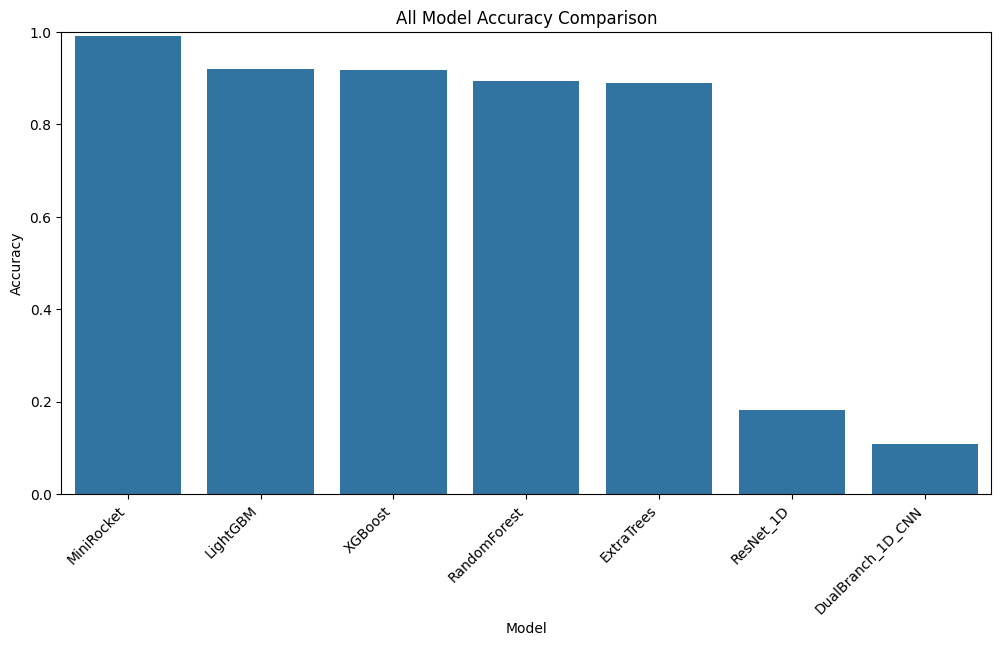

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.xticks(rotation=45, ha="right")
plt.title("All Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

Best Model: MiniRocket


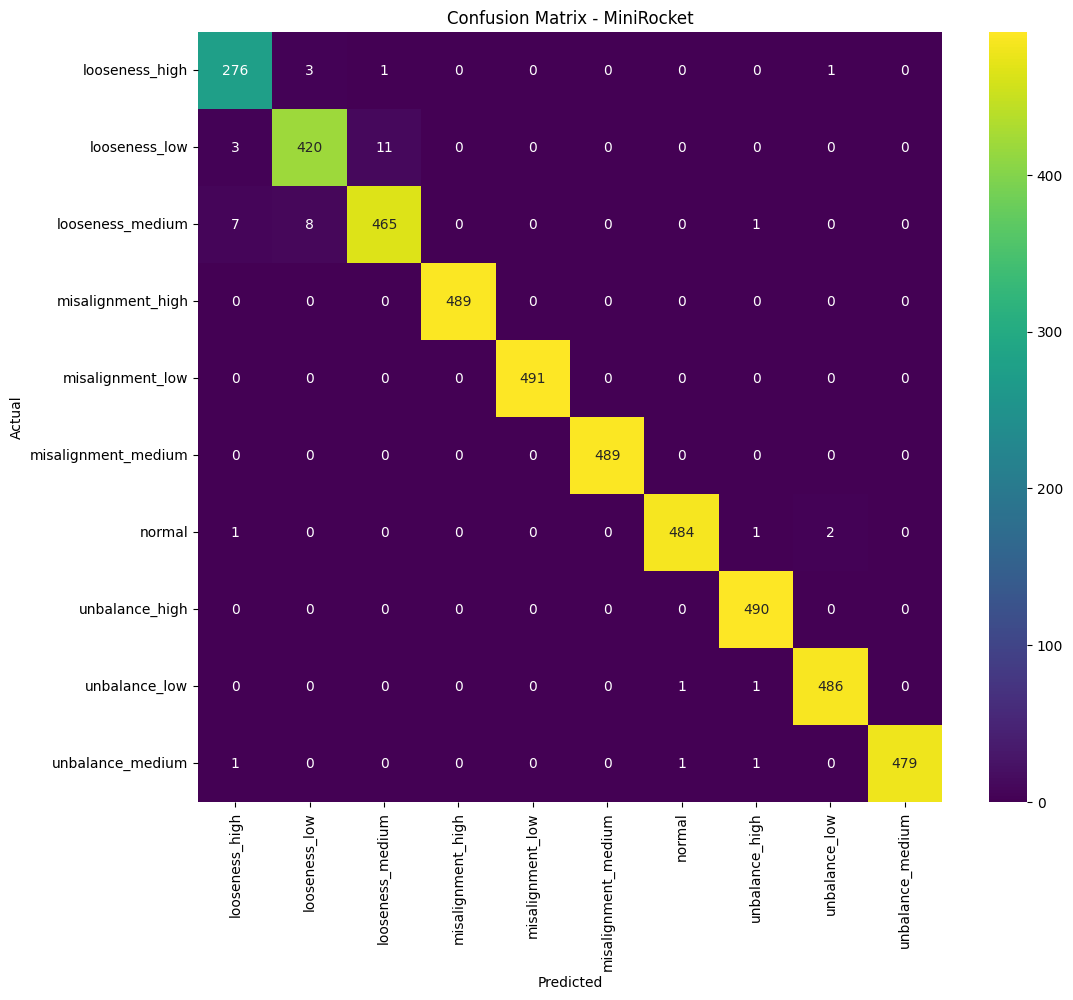

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

if best_model_name == "MiniRocket":
    best_pred = mr_pred
elif best_model_name in ["ExtraTrees", "RandomForest", "XGBoost", "LightGBM"]:
    best_pred = best_model.predict(X_test_feat)
else:
    best_pred = np.argmax(best_model.predict(X_test_raw), axis=1)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()